# Axolotl telencephalon — Regeneration

**Dataset:** `data/axolotl_regene/raw/rna.h5ad`. See `data/axolotl_regene/README.md`.

## Step 1 — Setup

In [1]:
import sys
import base64
from pathlib import Path

%load_ext autoreload
%autoreload 2

_cwd = Path.cwd()
project_root = _cwd if (_cwd / "model").is_dir() else _cwd.parent
sys.path.insert(0, str(project_root))

import scanpy as sc
import scipy.sparse as sparse
import torch
from IPython.display import HTML, SVG, display
from scipy.spatial.distance import pdist, squareform

from model.train import CellSTICConfig
from pipeline import run_cellstic
from pipeline.analyzer import TimeSequenceAnalysis
from utils.tools import SpatialPreprocessorUtils
from utils.tools.seed_utils import set_global_seed

set_global_seed()


def display_svg_grid(paths, n_cols=None, max_width=280):
    paths = [Path(p) for p in paths]
    if not paths:
        print("No SVG files found to display.")
        return
    if n_cols is None:
        n_cols = min(3, len(paths))
    rows = []
    for i in range(0, len(paths), n_cols):
        cells = []
        for path in paths[i : i + n_cols]:
            uri = "data:image/svg+xml;base64," + base64.b64encode(path.read_bytes()).decode("ascii")
            cells.append(
                f'<td style="width:{100 / n_cols:.2f}%;padding:4px;text-align:center">'
                f'<img src="{uri}" style="width:100%;max-width:{max_width}px;height:auto;"/>'
                f"</td>"
            )
        cells.extend(f'<td style="width:{100 / n_cols:.2f}%"></td>' for _ in range(n_cols - len(cells)))
        rows.append("<tr>" + "".join(cells) + "</tr>")
    display(HTML(f'<table style="width:100%;table-layout:fixed;border-collapse:collapse"><tbody>{"".join(rows)}</tbody></table>'))

/home/wangshuai/anaconda3/envs/spaGem/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2 — Configuration

In [2]:
cfg = CellSTICConfig()
cfg.model.graph.knn_top_k = 20
cfg.model.graph.cluster_size = 30
cfg.model.graph.expression_percentile = 95
cfg.model.graph.n_spots = 4
cfg.model.tree.hierarchy_method = "balanced"
cfg.train.ccc.sampling_rate = 0.3
cfg.train.ccc.learning_rate = 0.004
cfg.train.ccc.epochs = 200
cfg.train.feat.learning_rate = 0.003
cfg.train.feat.epochs = 1000
cfg.train.feat.n_clusters = 10
cfg.train.feat.weight_modality = 0.4
cfg.train.feat.entropy_weight = 0.4

# --- dataset-specific (regeneration) ---
BATCH_TO_STAGE = {
    "Injury_2DPI_rep1_SS200000147BL_D5": "regeneration_2",
    "Injury_5DPI_rep1_SS200000147BL_D2": "regeneration_5",
    "Injury_10DPI_rep1_SS200000147BL_B5": "regeneration_10",
    "Injury_15DPI_rep4_FP200000266TR_E4": "regeneration_15",
    "Injury_20DPI_rep2_SS200000147BL_B4": "regeneration_20",
    "Injury_30DPI_rep2_FP200000264BL_A6": "regeneration_30",
    "Injury_60DPI_rep3_FP200000264BL_A6": "regeneration_60",
    "Injury_control_FP200000239BL_E3": "regeneration_control",
}
STAGE_ORDER = [
    "regeneration_2",
    "regeneration_5",
    "regeneration_10",
    "regeneration_15",
    "regeneration_20",
    "regeneration_30",
    "regeneration_60",
    "regeneration_control",
]

work_dir = project_root / "data" / "axolotl_regene"
raw_path = work_dir / "raw"
result_path = work_dir / "result"

ligand_receptor_map = {
    "WNT7B": ["FZD5"],
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device:         {device}")
print(f"Ligand entries: {len(ligand_receptor_map)}")
print(f"Raw RNA:        {raw_path / 'rna.h5ad'}")

Device:         cuda
Ligand entries: 1
Raw RNA:        /home/wangshuai/project/CellSTIC/data/axolotl_regene/raw/rna.h5ad


## Step 3 — Load, preprocess, and run CellSTIC

Load `raw/rna.h5ad` once, subset by `obs['Batch']`, preprocess each stage, and save to `result/<stage>/cellstic_result.h5ad`.

In [3]:
rna_full = sc.read_h5ad(raw_path / "rna.h5ad")
rna_full.obs_names_make_unique()

gene_names = rna_full.var_names.astype(str)
if gene_names.str.contains(r"\|").any():
    rna_full.var_names = gene_names.str.split("|", n=1).str[0].str.strip()
    rna_full.var_names_make_unique()

if "spatial" not in rna_full.obsm:
    if "x" in rna_full.obs and "y" in rna_full.obs:
        rna_full.obsm["spatial"] = rna_full.obs[["x", "y"]].to_numpy()
    else:
        raise ValueError("Spatial coordinates not found.")

batch_series = rna_full.obs["Batch"].astype(str)
results = {}
# for batch_name, stage in BATCH_TO_STAGE.items():
#     sel = batch_series.eq(batch_name)
#     if not sel.any():
#         continue

#     rna_adata = rna_full[sel].copy()
#     rna_adata.var["mt"] = rna_adata.var_names.astype(str).str.startswith("MT-")
#     sc.pp.calculate_qc_metrics(rna_adata, percent_top=None, log1p=False, inplace=True)
#     sc.pp.highly_variable_genes(rna_adata, flavor="seurat_v3", n_top_genes=3000)
#     sc.pp.normalize_total(rna_adata, target_sum=1e4)
#     sc.pp.log1p(rna_adata)
#     rna_adata.obsm["feat"] = SpatialPreprocessorUtils.pca(
#         rna_adata[:, rna_adata.var["highly_variable"]], n_comps=500
#     )
#     rna_adata.obsp["spatial_distances"] = sparse.csr_matrix(
#         squareform(pdist(rna_adata.obsm["spatial"], metric="euclidean"))
#     )
#     rna_adata.obs["stage"] = stage
#     rna_adata.obs["organ"] = "telencephalon"

#     run_model_path = work_dir / "model" / stage
#     run_result_path = result_path / stage
#     run_model_path.mkdir(parents=True, exist_ok=True)
#     run_result_path.mkdir(parents=True, exist_ok=True)

#     print(f"\n=== stage={stage}, batch={batch_name}, cells={rna_adata.n_obs} ===")
#     result = run_cellstic(
#         modality_datas=[rna_adata],
#         ligand_receptor_map=ligand_receptor_map,
#         model_path=run_model_path,
#         output_path=run_result_path,
#         config=cfg,
#         device=device,
#         auto_n_clusters=7,
#     )
#     results[stage] = result
#     print(f"Saved to {result.adata_path}")

# print(f"\nCompleted {len(results)} runs.")

## Step 4 — Initialize time-series analysis

Load per-run ``result/<stage>/cellstic_result.h5ad`` files via ``result_root``.

In [4]:
time_output_path = work_dir / "time_series"
time_output_path.mkdir(parents=True, exist_ok=True)

annotation_filter = ["telencephalon"]
lr_filter = ["WNT7B-FZD5"]
region_lr_map = {"telencephalon": "WNT7B-FZD5"}

result_files = sorted(result_path.glob("*/cellstic_result.h5ad"))
print(f"Found {len(result_files)} result files under {result_path}")
for path in result_files:
    print(f"  {path.parent.name}")

time_sequence_analysis = TimeSequenceAnalysis(
    output_path=time_output_path,
    result_root=result_path,
    stages=STAGE_ORDER,
    annotation_filter=annotation_filter,
    lr_filter=lr_filter,
    fig_format="svg",
    cell_type_key="Annotation",
)

print(f"Stages:          {time_sequence_analysis.stages}")
print(f"Analysis output: {time_output_path}")

Found 8 result files under /home/wangshuai/project/CellSTIC/data/axolotl_regene/result
  regeneration_10
  regeneration_15
  regeneration_2
  regeneration_20
  regeneration_30
  regeneration_5
  regeneration_60
  regeneration_control
Stages:          ['regeneration_2', 'regeneration_5', 'regeneration_10', 'regeneration_15', 'regeneration_20', 'regeneration_30', 'regeneration_60', 'regeneration_control']
Analysis output: /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series


## Step 5 — Cell number over stages

[TimeSeriesMetrics] Stage regeneration_2: {'telencephalon': 7668}
[TimeSeriesMetrics] Stage regeneration_5: {'telencephalon': 8106}
[TimeSeriesMetrics] Stage regeneration_10: {'telencephalon': 9440}
[TimeSeriesMetrics] Stage regeneration_15: {'telencephalon': 9676}
[TimeSeriesMetrics] Stage regeneration_20: {'telencephalon': 11319}
[TimeSeriesMetrics] Stage regeneration_30: {'telencephalon': 9252}
[TimeSeriesMetrics] Stage regeneration_60: {'telencephalon': 10964}
[TimeSeriesMetrics] Stage regeneration_control: {'telencephalon': 11698}
[TimeSeriesMetrics] Plot saved: /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/cell_number_over_stages/cell_number_over_stages.svg
[TimeSeriesMetrics] Cell-number line plot saved to /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/cell_number_over_stages/cell_number_over_stages.svg


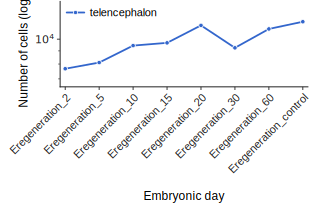

In [5]:
time_sequence_analysis.count_cell_number(recompute=True, font_size=12)
display(SVG(filename=str(time_output_path / "cell_number_over_stages" / "cell_number_over_stages.svg")))

## Step 6 — Edge number over stages

In [6]:
time_sequence_analysis.count_edge_number(recompute=True, font_size=12)
display_svg_grid(sorted((time_output_path / "edge_number_over_stages").glob("*.svg")), n_cols=2)

[TimeSeriesMetrics] Processing stage regeneration_2 (1/8)...
[TimeSeriesMetrics] Processing stage regeneration_5 (2/8)...
[TimeSeriesMetrics] Processing stage regeneration_10 (3/8)...
[TimeSeriesMetrics] Processing stage regeneration_15 (4/8)...
[TimeSeriesMetrics] Processing stage regeneration_20 (5/8)...
[TimeSeriesMetrics] Processing stage regeneration_30 (6/8)...
[TimeSeriesMetrics] Processing stage regeneration_60 (7/8)...
[TimeSeriesMetrics] Processing stage regeneration_control (8/8)...
[TimeSeriesMetrics] Organ telencephalon: ['WNT7B-FZD5']
[TimeSeriesMetrics] Plot saved: /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/edge_number_over_stages/edge_number_over_stages_telencephalon.svg
[TimeSeriesMetrics] Edge-number plot for telencephalon saved to /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/edge_number_over_stages/edge_number_over_stages_telencephalon.svg


,


## Step 7 — Efficiency metrics

  Spatial metrics: regeneration_2 / telencephalon (n_cells=7668) ...
  Spatial metrics: regeneration_5 / telencephalon (n_cells=8106) ...
  Spatial metrics: regeneration_10 / telencephalon (n_cells=9440) ...
  Spatial metrics: regeneration_15 / telencephalon (n_cells=9676) ...
  Spatial metrics: regeneration_20 / telencephalon (n_cells=11319) ...
  Spatial metrics: regeneration_30 / telencephalon (n_cells=9252) ...
  Spatial metrics: regeneration_60 / telencephalon (n_cells=10964) ...
  Spatial metrics: regeneration_control / telencephalon (n_cells=11698) ...
[Efficiency] Metrics figure saved to /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/efficiency_metrics/efficiency_metrics.svg.


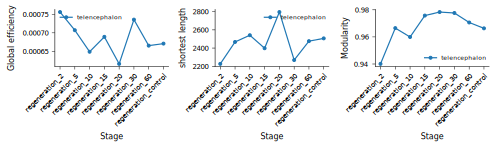

In [7]:
time_sequence_analysis.plot_efficiency_metrics(recompute=True, region_lr_map=region_lr_map, font_size=8)
display(SVG(filename=str(time_output_path / "efficiency_metrics" / "efficiency_metrics.svg")))

## Step 8 — Cell-type strength over stages

In [8]:
time_sequence_analysis.plot_celltype_strength_bars(recompute=True, region_lr_map=region_lr_map, font_size=8)
display_svg_grid(sorted((time_output_path / "celltype_strength_over_stages").glob("*.svg")), n_cols=2)

[CellTypeStrengthOverStages] Aggregate: regeneration_2 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_5 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_10 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_15 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_20 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_30 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_60 / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Aggregate: regeneration_control / telencephalon / WNT7B-FZD5
[CellTypeStrengthOverStages] Figure saved for telencephalon -> /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/celltype_strength_over_stages/celltype_strength_over_stages_telencephalon.svg
[CellTypeStrengthOverStages] Cell-type strength figures saved under /home/wangshuai/project/CellSTIC/data/axolo

,


## Step 9 — Graph density over stages

In [9]:
time_sequence_analysis.plot_graph_density_over_stages(recompute=True, font_size=12)
display_svg_grid(sorted((time_output_path / "graph_density_over_stages").glob("*.svg")), n_cols=2)

[TimeSeriesDensity] Processing stage regeneration_2 (1/8)...
[TimeSeriesDensity] Processing stage regeneration_5 (2/8)...
[TimeSeriesDensity] Processing stage regeneration_10 (3/8)...
[TimeSeriesDensity] Processing stage regeneration_15 (4/8)...
[TimeSeriesDensity] Processing stage regeneration_20 (5/8)...
[TimeSeriesDensity] Processing stage regeneration_30 (6/8)...
[TimeSeriesDensity] Processing stage regeneration_60 (7/8)...
[TimeSeriesDensity] Processing stage regeneration_control (8/8)...
[TimeSeriesDensity] Density figure saved for telencephalon -> /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/graph_density_over_stages/density_over_stages_telencephalon.svg
[TimeSeriesDensity] Density curves saved under /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/graph_density_over_stages.


,


## Step 10 — Strong nodes over stages

[StrongNodesOverStages] Strong-node curves figure saved to /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/strong_nodes_over_stages/strong_nodes_over_stages.svg.


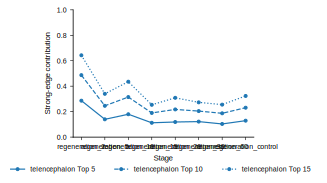

In [10]:
time_sequence_analysis.plot_strong_nodes_over_stages(recompute=True, region_lr_map=region_lr_map, font_size=8)
display(SVG(filename=str(time_output_path / "strong_nodes_over_stages" / "strong_nodes_over_stages.svg")))

## Step 11 — Strength vs spatial distance

In [11]:
time_sequence_analysis.plot_strength_vs_distance_over_stages(recompute=True, region_lr_map=region_lr_map, font_size=12)
display_svg_grid(sorted((time_output_path / "strength_vs_distance_over_stages").glob("*.svg")), n_cols=2)

[StrengthDistance] Figure saved for telencephalon -> /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/strength_vs_distance_over_stages/strength_vs_distance_telencephalon.svg
[StrengthDistance] Strength–distance figures saved under /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/strength_vs_distance_over_stages.


,


## Step 12 — CCDF degree and strength

Load: regeneration_2 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_5 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_10 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_15 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_20 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_30 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_60 / telencephalon / WNT7B-FZD5 ...
Load: regeneration_control / telencephalon / WNT7B-FZD5 ...
[CCDF] CCDF degree/strength figure saved to /home/wangshuai/project/CellSTIC/data/axolotl_regene/time_series/ccdf_degree_strength/ccdf_degree_strength.svg.


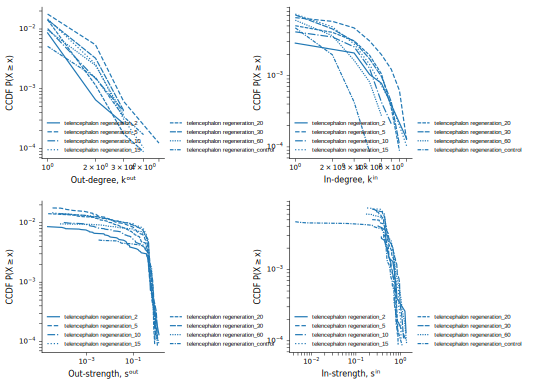

In [12]:
time_sequence_analysis.plot_ccdf_degree_strength(recompute=True, region_lr_map=region_lr_map, font_size=8)
display(SVG(filename=str(time_output_path / "ccdf_degree_strength" / "ccdf_degree_strength.svg")))